In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-file/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv


# =========================================
# STEP 0: Import Libraries
# =========================================


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Visualization style

In [8]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

# =========================================
# STEP 2: Load Dataset
# =========================================

In [9]:

file_path = "/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-file/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nSummary Statistics:")
print(df.describe())


Dataset Loaded Successfully

Dataset Shape: (5288, 15)

Columns:
Index(['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose',
       'height', 'weight', 'bmi', 'family_diabetes', 'hypertensive',
       'family_hypertension', 'cardiovascular_disease', 'stroke', 'diabetic'],
      dtype='object')

First 5 Rows:
   age  gender  pulse_rate  systolic_bp  diastolic_bp  glucose  height  \
0   42  Female          66          110            73     5.88    1.65   
1   35  Female          60          125            68     5.71    1.47   
2   62  Female          57          127            74     6.85    1.52   
3   73    Male          55          193           112     6.28    1.63   
4   68  Female          71          150            81     5.71    1.42   

   weight    bmi  family_diabetes  hypertensive  family_hypertension  \
0    70.2  25.75                0             0                    0   
1    42.5  19.58                0             0                    0   
2    47.0

# =========================================
# STEP 3: Exploratory Data Analysis
# =========================================

# -----------------------------
# Class Distribution
# -----------------------------


/tmp/ipykernel_55/4158777661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetic', data=df, palette="viridis")
/tmp/ipykernel_55/4158777661.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["diabetic"].value_counts()[i] + 20,
/tmp/ipykernel_55/4158777661.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["diabetic"].value_counts()[i],
/tmp/ipykernel_55/4158777661.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated.

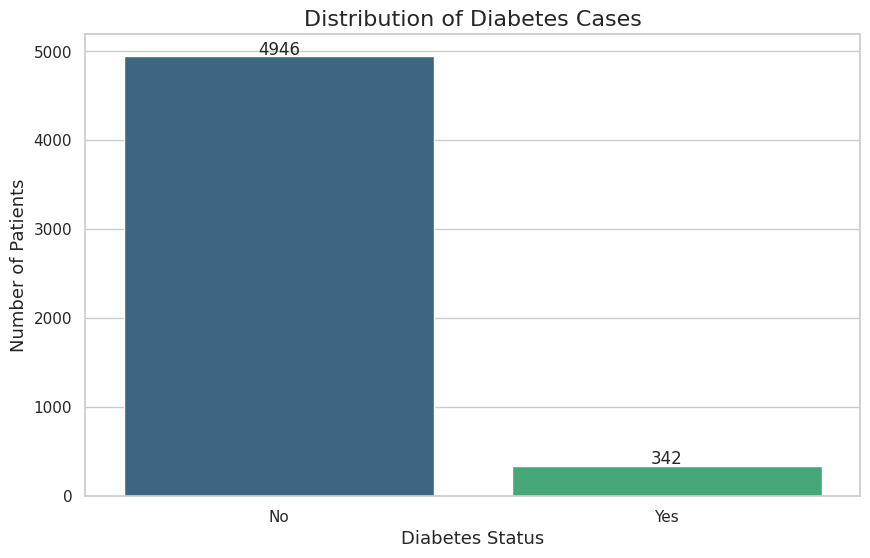

In [10]:

plt.figure()
sns.countplot(x='diabetic', data=df, palette="viridis")

plt.title("Distribution of Diabetes Cases")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")

for i in range(len(df["diabetic"].value_counts())):
    plt.text(i,
             df["diabetic"].value_counts()[i] + 20,
             df["diabetic"].value_counts()[i],
             ha='center',
             fontsize=12)

plt.show()


# =========================================
# Numerical Feature Distribution
# =========================================


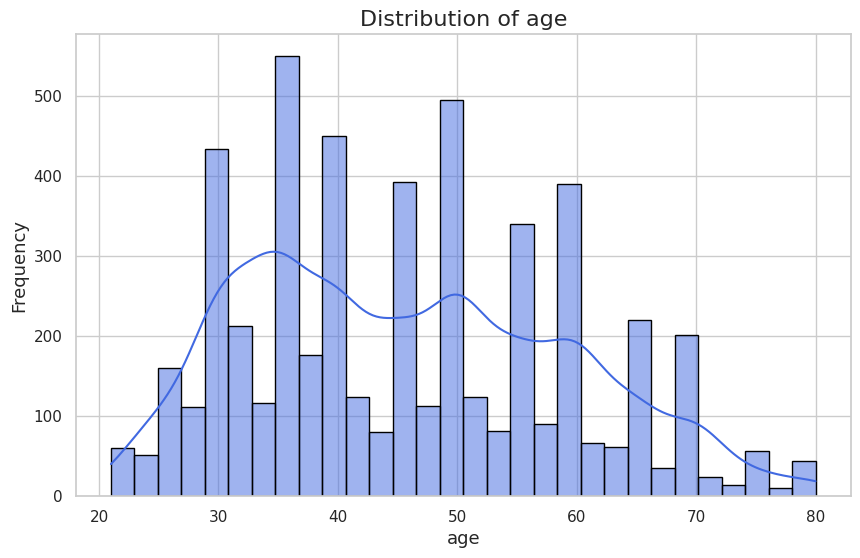

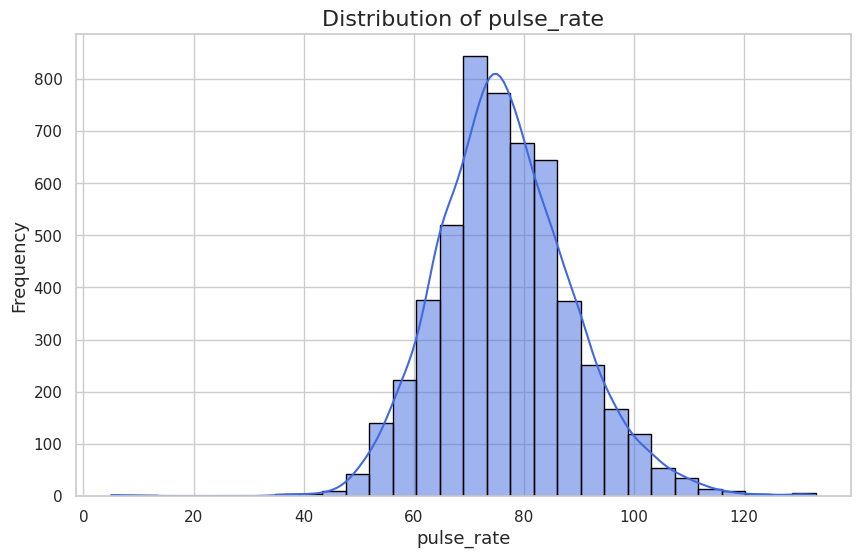

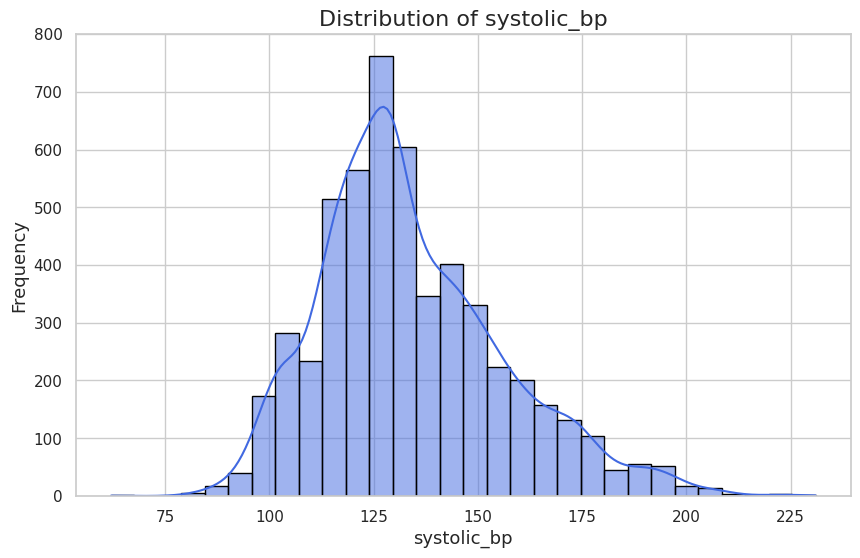

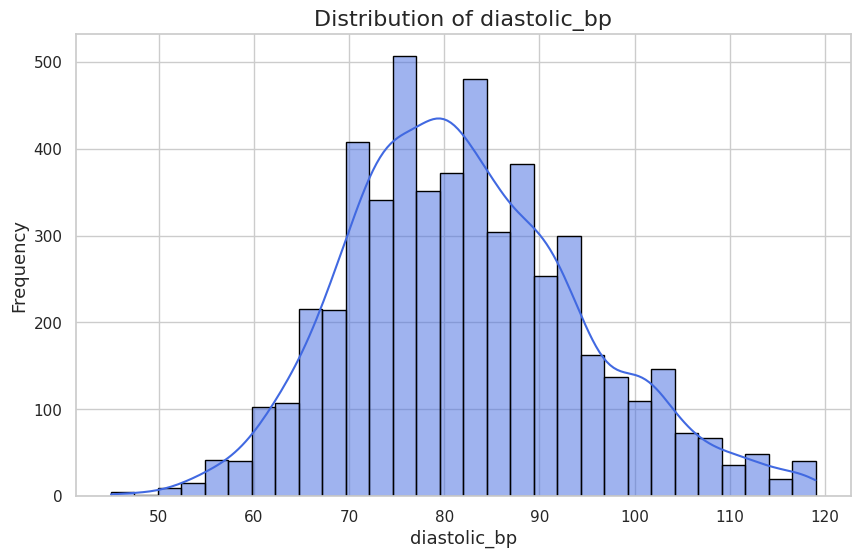

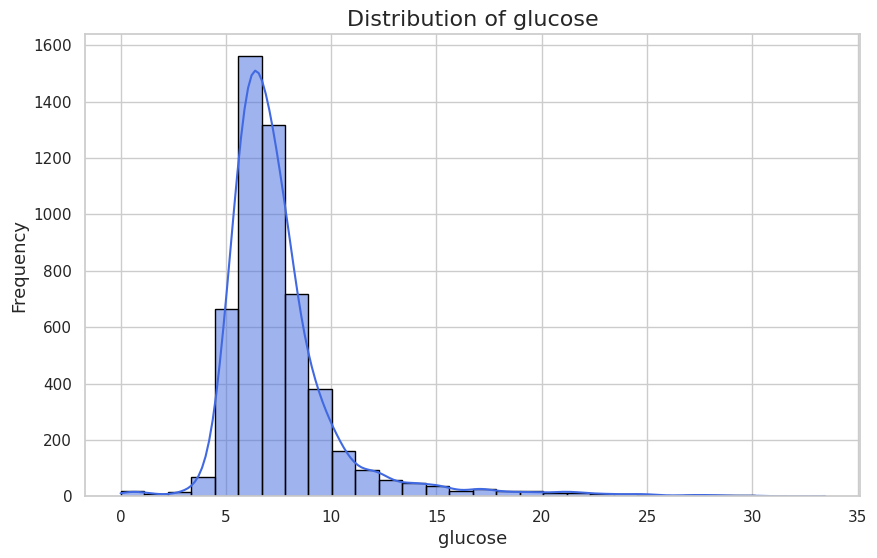

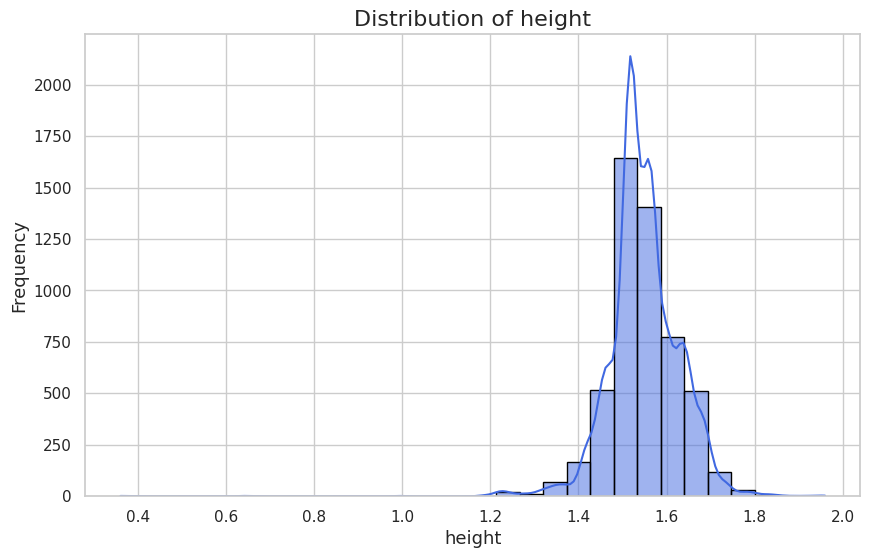

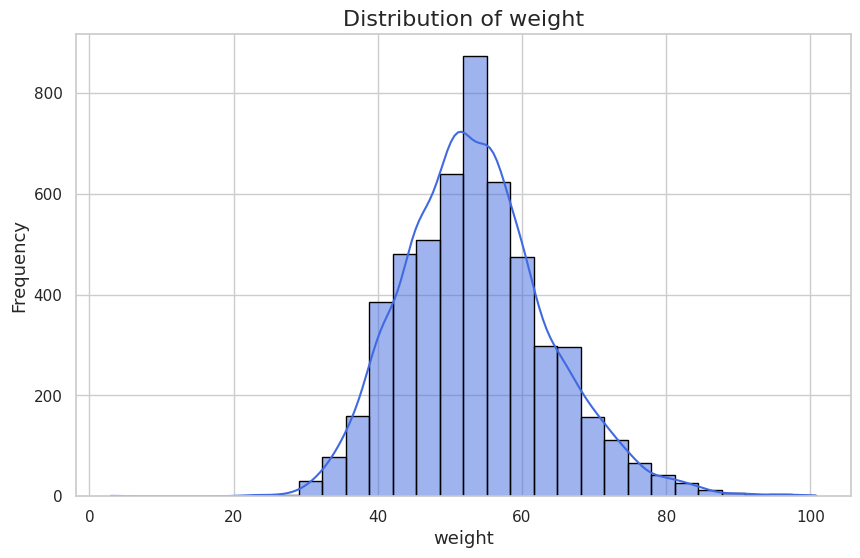

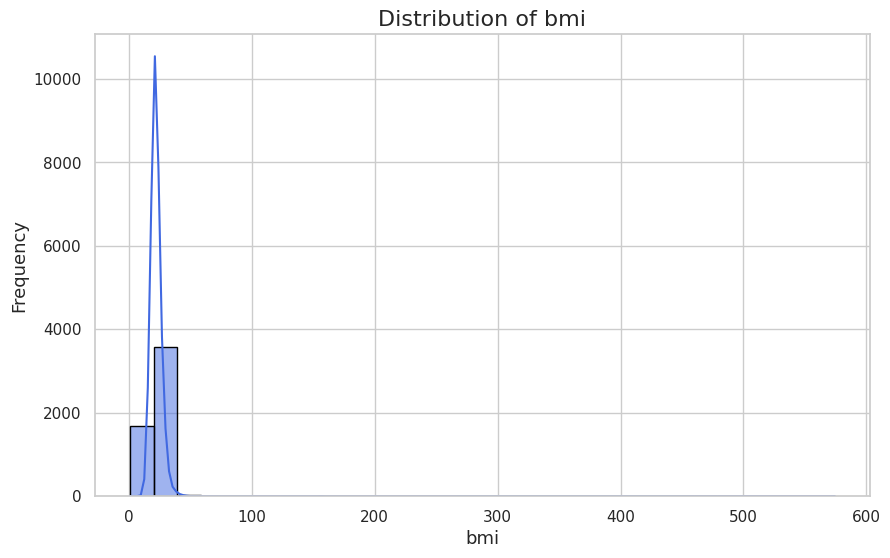

In [11]:
numerical_features = [
    "age",
    "pulse_rate",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "height",
    "weight",
    "bmi"
]

for feature in numerical_features:

    plt.figure()

    sns.histplot(
        df[feature],
        kde=True,
        bins=30,
        color="royalblue",
        edgecolor="black"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

# =========================================
# Boxplots for Outlier Detection
# =========================================


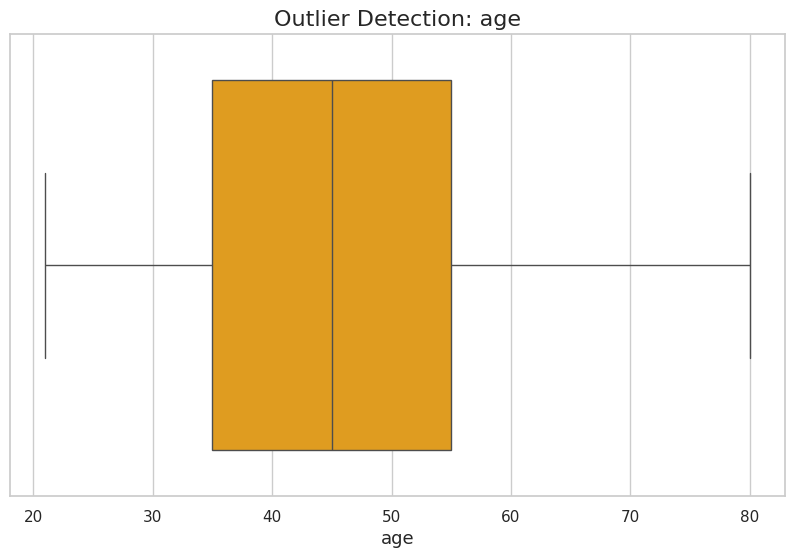

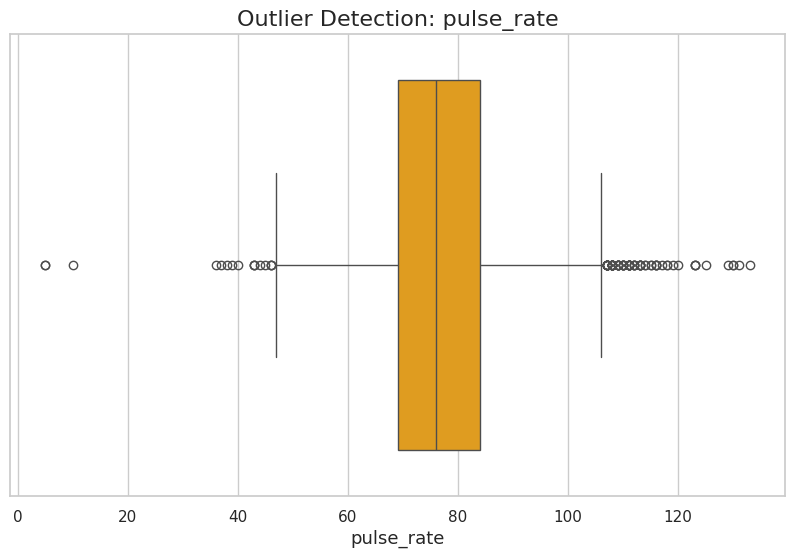

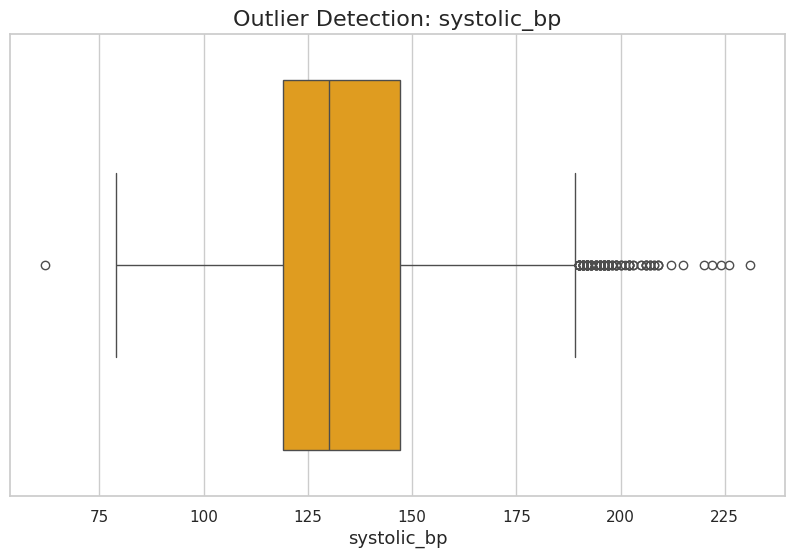

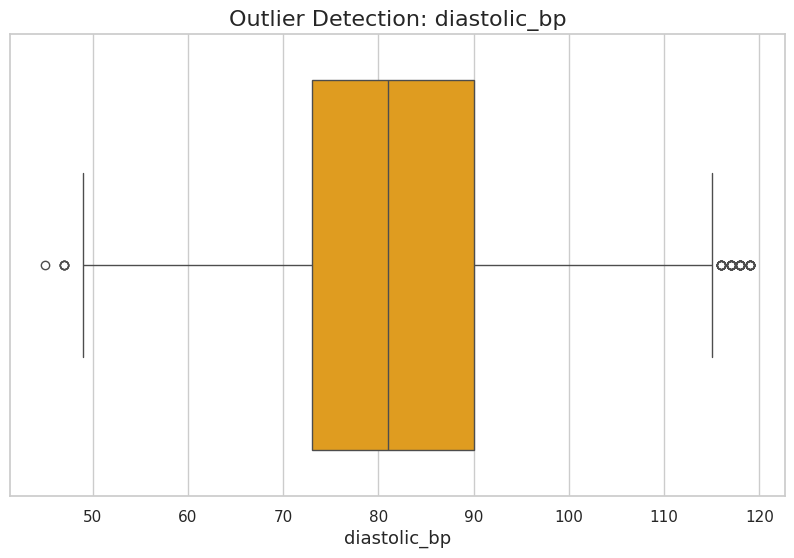

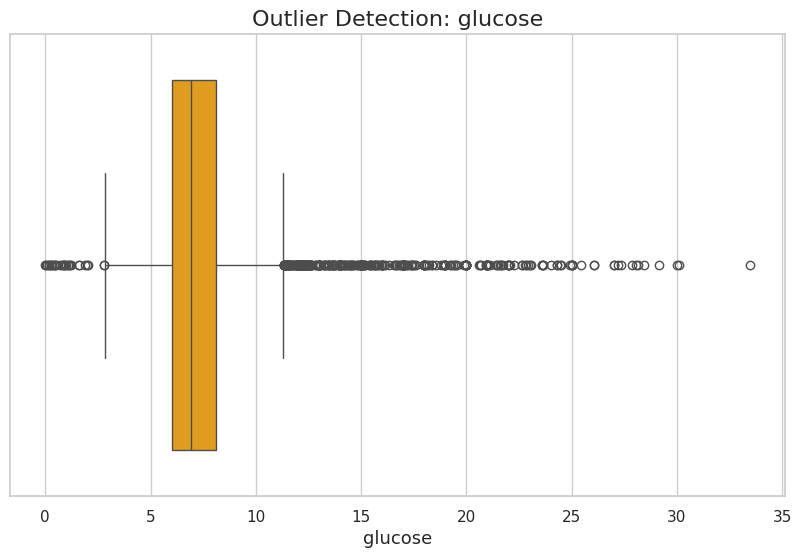

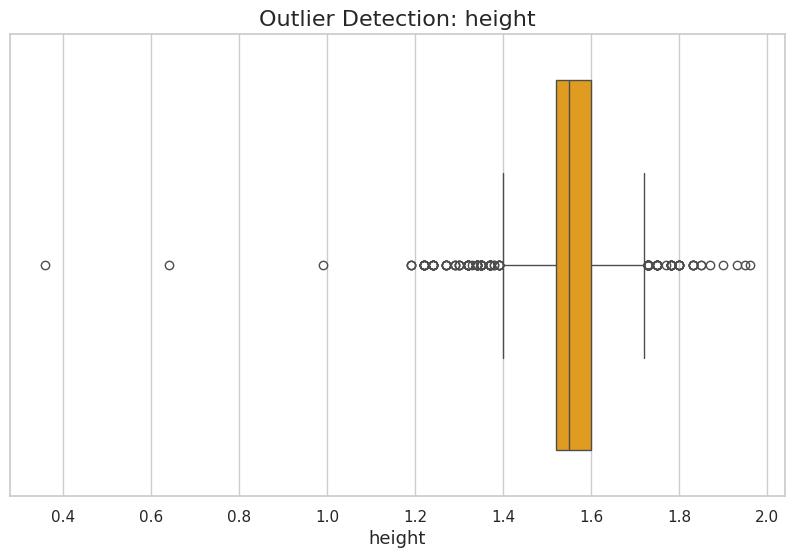

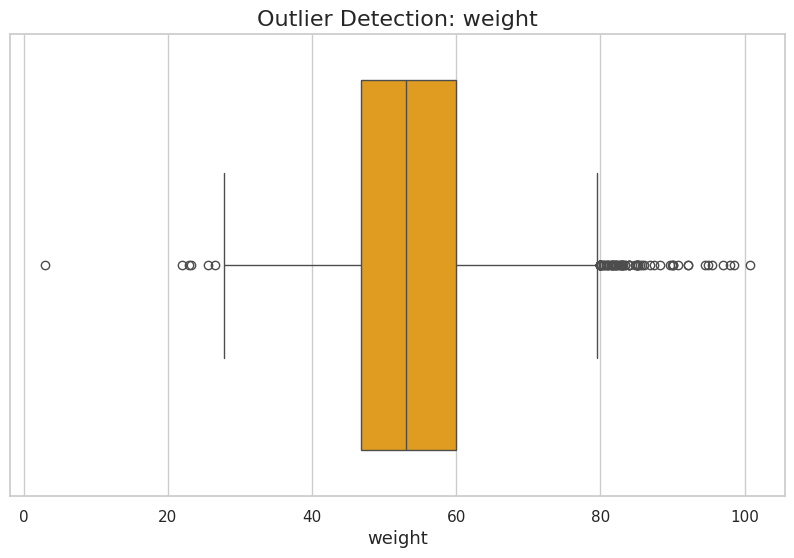

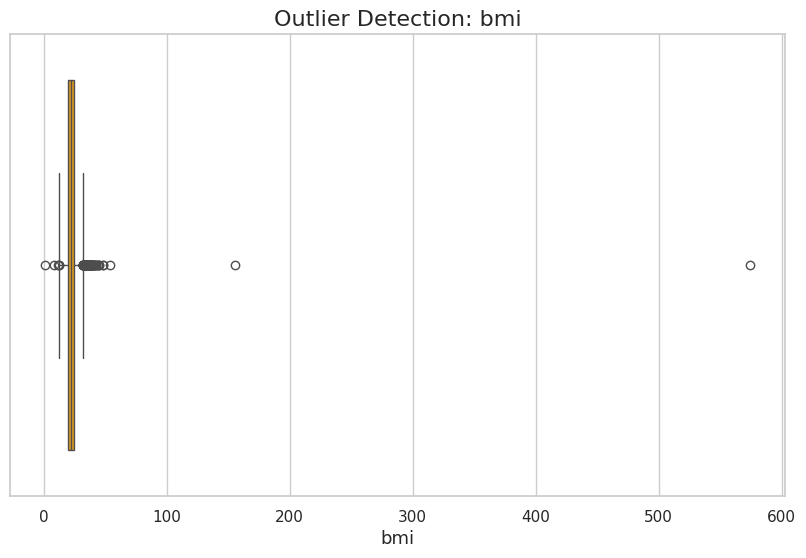

In [12]:
for feature in numerical_features:

    plt.figure()

    sns.boxplot(
        x=df[feature],
        color="orange"
    )

    plt.title(f"Outlier Detection: {feature}")
    plt.xlabel(feature)

    plt.show()


# =========================================
# Correlation Heatmap
# =========================================

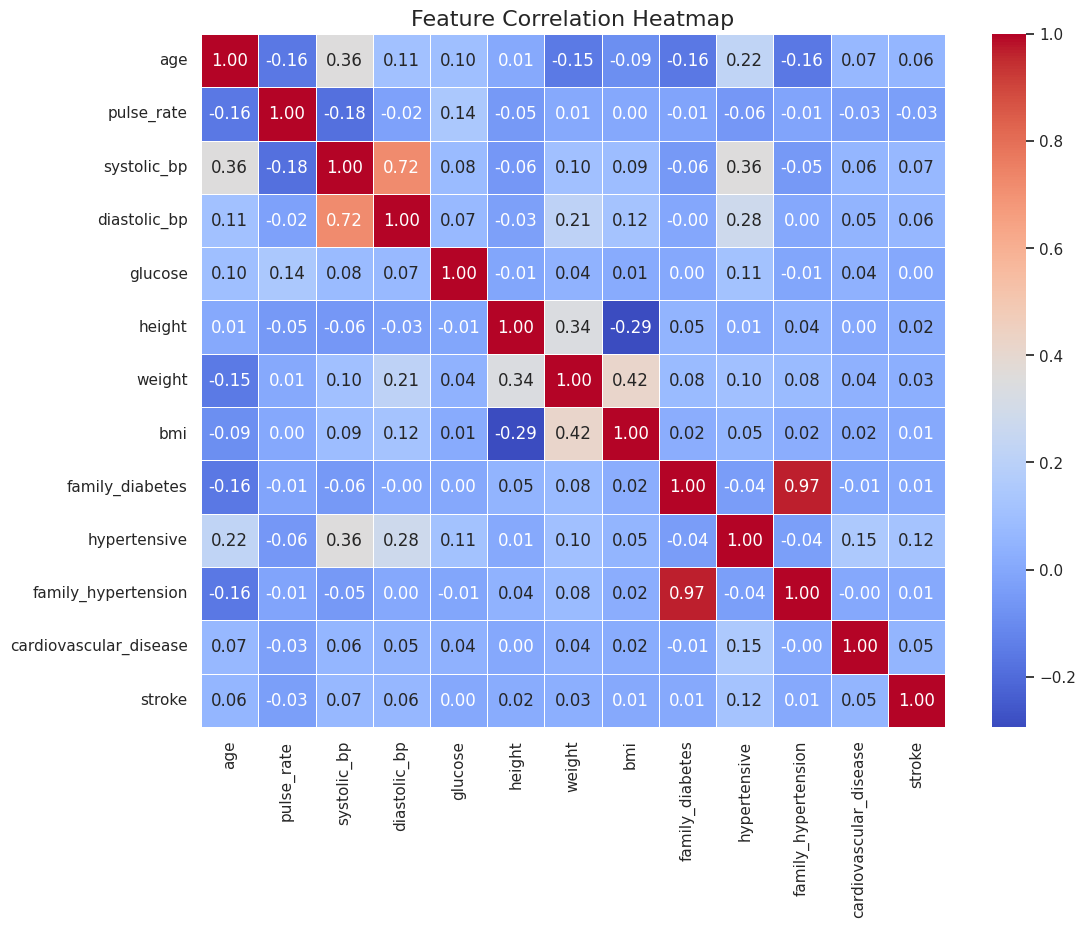

In [13]:

plt.figure(figsize=(12,9))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()



# =========================================
# Relationship Between Important Features and Diabetes
# =========================================


/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


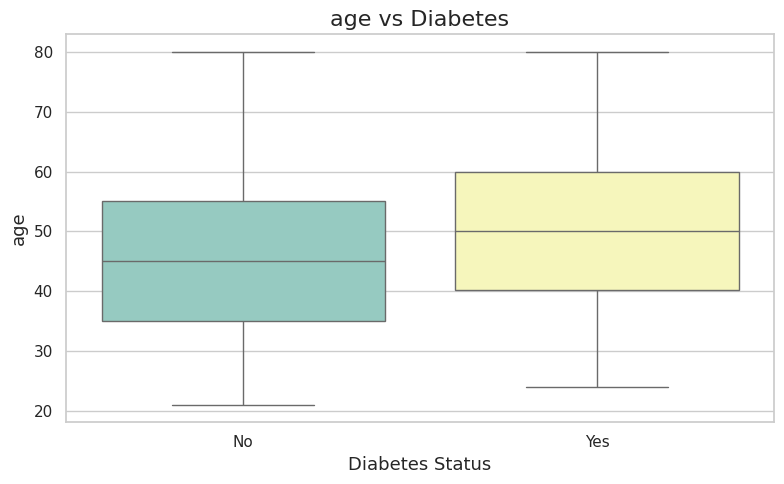

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


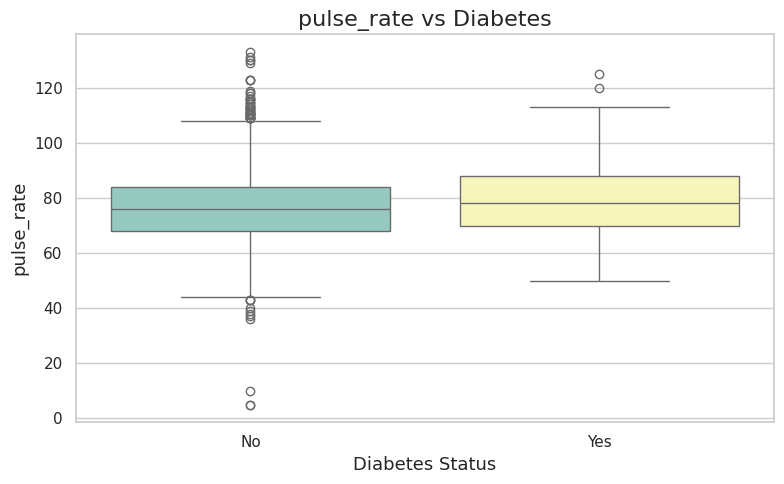

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


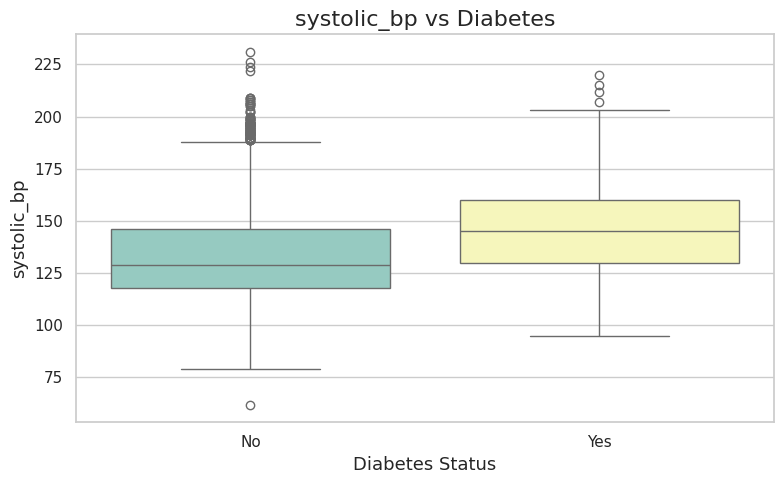

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


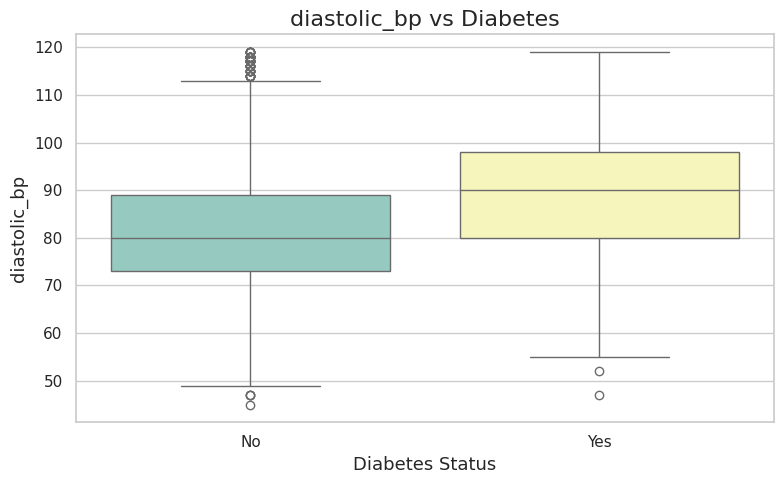

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


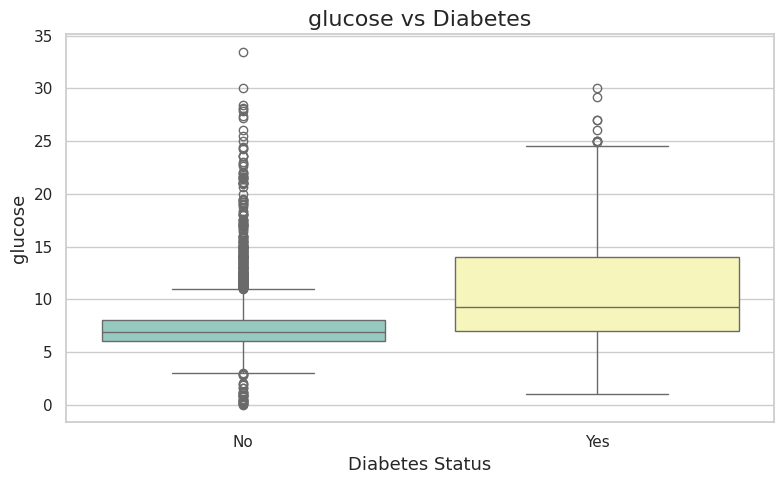

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


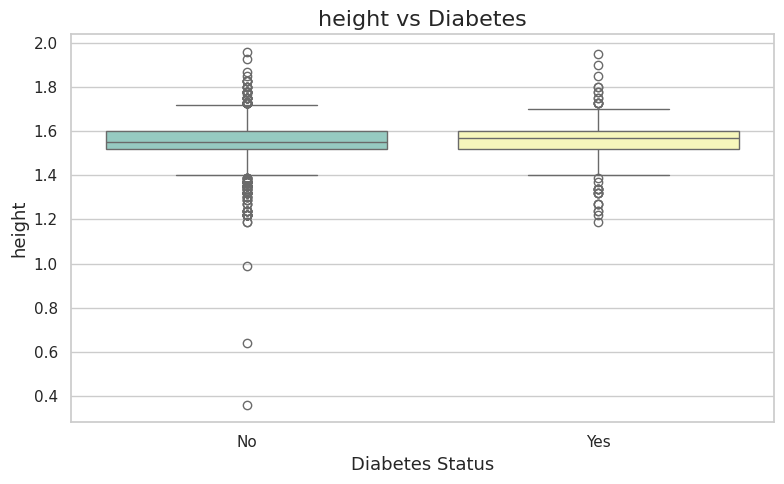

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


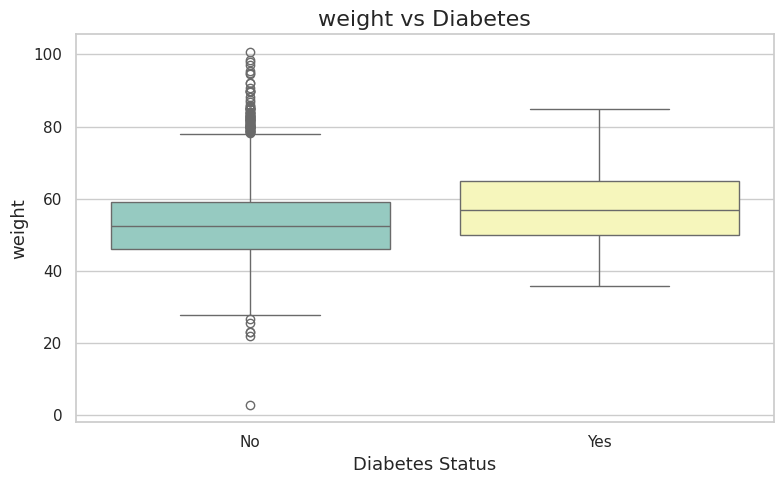

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


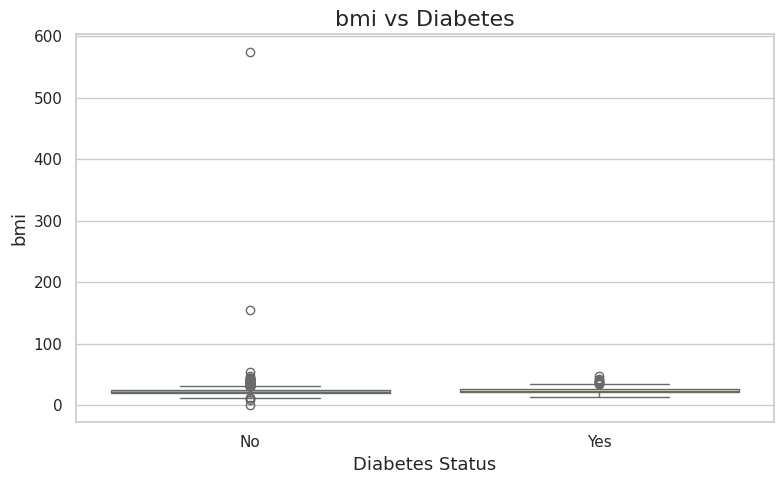

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


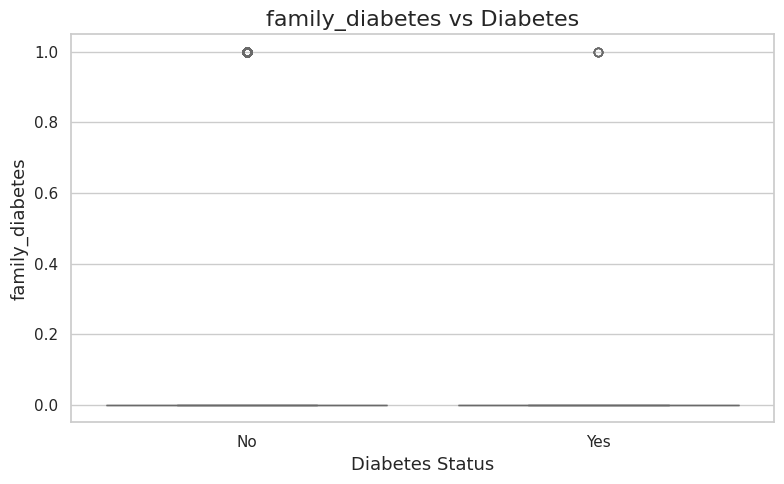

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


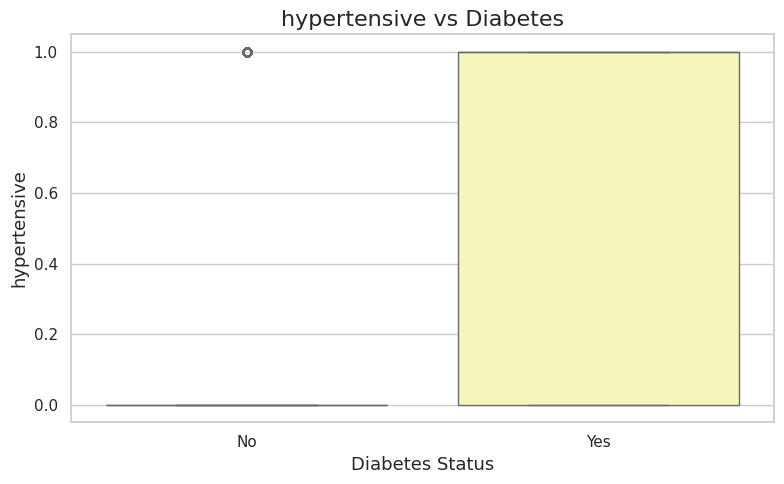

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


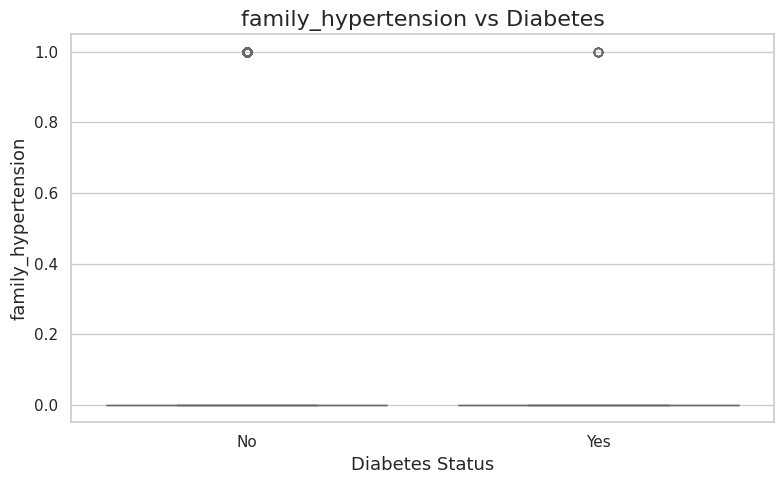

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


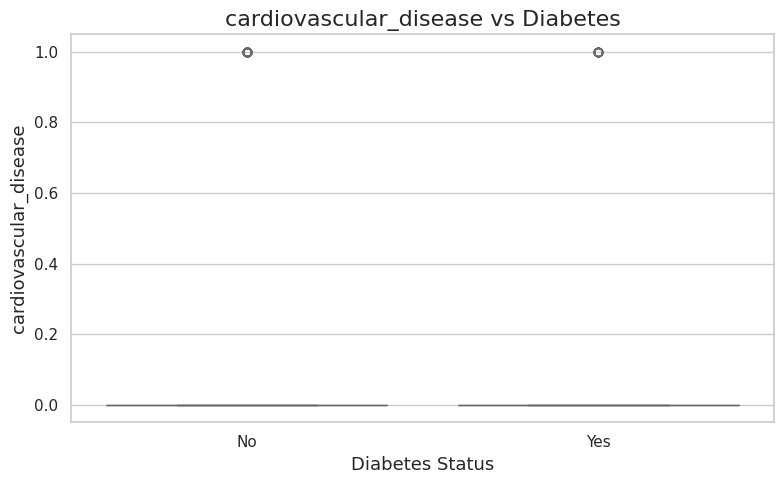

/tmp/ipykernel_55/3711671560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


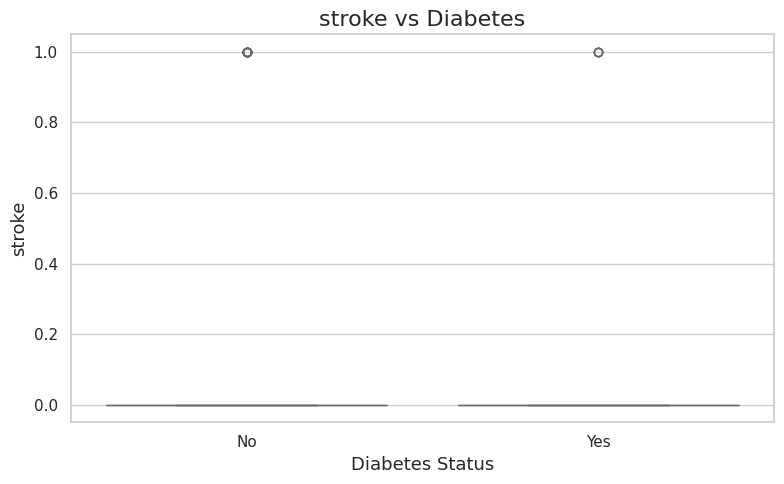

In [15]:
# =========================================
# Relationship Between ALL Numerical Features and Diabetes
# =========================================

# automatically detect numerical columns
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()

# plot relationship
for feature in numerical_features:

    if feature != "diabetic":   # safely skip target column

        plt.figure(figsize=(8,5))

        sns.boxplot(
            x="diabetic",
            y=feature,
            data=df,
            palette="Set3"
        )

        plt.title(f"{feature} vs Diabetes")
        plt.xlabel("Diabetes Status")
        plt.ylabel(feature)

        plt.tight_layout()
        plt.show()


# =========================================
# STEP 4: Data Cleaning
# =========================================

In [18]:
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:", df.shape)

# Replace invalid values
df['bmi'].replace(0, np.nan, inplace=True)
df['glucose'].replace(0, np.nan, inplace=True)

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)


Missing Values:
age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64

Dataset shape after removing duplicates: (5288, 15)


/tmp/ipykernel_55/4211981086.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].replace(0, np.nan, inplace=True)
/tmp/ipykernel_55/4211981086.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

# =========================================
# Encode Categorical Features
# =========================================

In [19]:
categorical_cols = [
    "gender",
    "family_diabetes",
    "hypertensive",
    "family_hypertension",
    "cardiovascular_disease",
    "stroke"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nEncoded Dataset Preview:")
print(df.head())



Encoded Dataset Preview:
   age  pulse_rate  systolic_bp  diastolic_bp  glucose  height  weight    bmi  \
0   42          66          110            73     5.88    1.65    70.2  25.75   
1   35          60          125            68     5.71    1.47    42.5  19.58   
2   62          57          127            74     6.85    1.52    47.0  20.24   
3   73          55          193           112     6.28    1.63    57.4  21.72   
4   68          71          150            81     5.71    1.42    36.0  17.79   

  diabetic  gender_Male  family_diabetes_1  hypertensive_1  \
0       No        False              False           False   
1       No        False              False           False   
2       No        False              False           False   
3       No         True              False           False   
4       No        False              False           False   

   family_hypertension_1  cardiovascular_disease_1  stroke_1  
0                  False                     False 

# =========================================
# STEP 5: Feature & Target Separation
# =========================================

In [20]:
X = df.drop("diabetic", axis=1)
y = df["diabetic"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (5288, 14)
Target Shape: (5288,)


# =========================================
# STEP 6: Train / Validation / Test Split
# =========================================

In [21]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset Split:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)



Dataset Split:
Training: (3701, 14)
Validation: (793, 14)
Testing: (794, 14)


# =========================================
# Feature Scaling
# =========================================

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed")

print("\nData ready for model training!")


Feature Scaling Completed

Data ready for model training!
